In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from IPython.display import display

Memeriksa folder: /content/drive/MyDrive/Colab Notebooks/DatasetKakao
Berhasil menemukan 10 citra kakao. Siap ditampilkan!
PREVIEW DATASET CITRA KAKAO


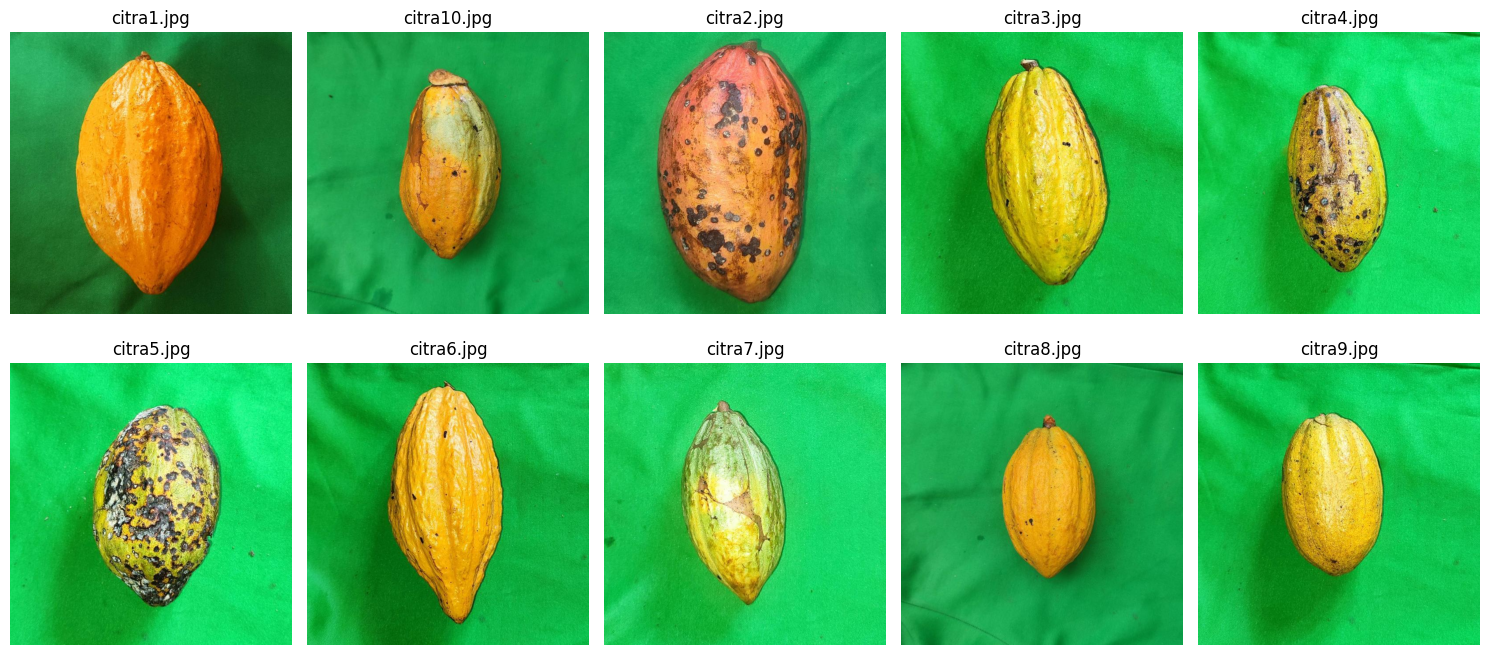

In [48]:
folder_path = '/content/drive/MyDrive/Colab Notebooks/DatasetKakao'
nama_file_output = '/content/drive/MyDrive/Colab Notebooks/Hasil_Klasifikasi_Kakao_Final.xlsx'

print(f"Memeriksa folder: {folder_path}")
file_list = [f for f in os.listdir(folder_path) if f.endswith((".jpg", ".jpeg", ".png"))]
file_list = sorted(file_list) # Mengurutkan nama file dari citra1 sampai citra10

if len(file_list) == 0:
    print("Peringatan: Tidak ada gambar di folder tersebut. Pastikan path benar!")
else:
    print(f"Berhasil menemukan {len(file_list)} citra kakao. Siap ditampilkan!")

    print("=========================================")
print("PREVIEW DATASET CITRA KAKAO")
print("=========================================")

# Menampilkan maksimal 10 gambar agar tampilan tetap rapi
jumlah_tampil = min(len(file_list), 10)
kolom = 5
baris = (jumlah_tampil // kolom) + (1 if jumlah_tampil % kolom != 0 else 0)

plt.figure(figsize=(15, 3.5 * baris))

for i, file_name in enumerate(file_list[:jumlah_tampil]):
    file_path = os.path.join(folder_path, file_name)
    img = cv2.imread(file_path)

    # OpenCV membaca gambar dalam format BGR, kita ubah ke RGB agar warnanya benar saat ditampilkan
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(baris, kolom, i + 1)
    plt.imshow(img_rgb)
    plt.title(file_name)
    plt.axis('off') # Menghilangkan garis sumbu X dan Y

plt.tight_layout()
plt.show()

In [49]:
print("Memulai proses ekstraksi fitur...\n")
data_fitur = []

for file_name in file_list:
    file_path = os.path.join(folder_path, file_name)

    src = cv2.imread(file_path)
    if src is None: continue

    src_resized = cv2.resize(src, (300, 300))

    # A. WARNA (HSV)
    hsv = cv2.cvtColor(src_resized, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    hue_mean = np.mean(h)
    saturation_mean = np.mean(s)

    # B. TEKSTUR (GLCM)
    gray = cv2.cvtColor(src_resized, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4], symmetric=True, normed=True)
    kontras = graycoprops(glcm, 'contrast').mean()
    homogenitas = graycoprops(glcm, 'homogeneity').mean()

    # C. BENTUK
    ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(cnt)
        keliling = cv2.arcLength(cnt, True)
    else:
        area = keliling = 0

    data_fitur.append([file_name, hue_mean, saturation_mean, kontras, homogenitas, area, keliling])

    # Cetak KESELURUHAN hasil ekstraksi fitur agar muncul di output
    print(f"-> {file_name:<12} | H: {hue_mean:.2f} | S: {saturation_mean:.2f} | Kontras: {kontras:.2f} | Homogenitas: {homogenitas:.4f} | Area: {area:.1f} | Keliling: {keliling:.1f}")

print("\nEkstraksi fitur 100% Selesai!")

Memulai proses ekstraksi fitur...

-> citra1.jpg   | H: 48.98 | S: 202.99 | Kontras: 67.81 | Homogenitas: 0.2432 | Area: 52232.5 | Keliling: 2097.4
-> citra10.jpg  | H: 62.26 | S: 212.53 | Kontras: 70.54 | Homogenitas: 0.3553 | Area: 89401.0 | Keliling: 1196.0
-> citra2.jpg   | H: 50.10 | S: 196.90 | Kontras: 192.81 | Homogenitas: 0.2054 | Area: 89399.0 | Keliling: 1197.7
-> citra3.jpg   | H: 57.87 | S: 227.59 | Kontras: 136.93 | Homogenitas: 0.1730 | Area: 89399.0 | Keliling: 1197.7
-> citra4.jpg   | H: 62.42 | S: 219.95 | Kontras: 276.91 | Homogenitas: 0.1524 | Area: 26372.0 | Keliling: 4459.3
-> citra5.jpg   | H: 62.15 | S: 208.24 | Kontras: 512.20 | Homogenitas: 0.1602 | Area: 19368.5 | Keliling: 3503.7
-> citra6.jpg   | H: 57.00 | S: 230.55 | Kontras: 131.47 | Homogenitas: 0.1786 | Area: 89396.5 | Keliling: 1199.1
-> citra7.jpg   | H: 64.25 | S: 208.27 | Kontras: 189.53 | Homogenitas: 0.1479 | Area: 89401.0 | Keliling: 1196.0
-> citra8.jpg   | H: 64.11 | S: 220.29 | Kontras: 33.68

In [50]:
kolom_fitur = ['Nama File', 'Rerata Hue', 'Rerata Saturation', 'Contrast (GLCM)', 'Homogeneity (GLCM)', 'Luas Area (Piksel)', 'Keliling (Piksel)']
df = pd.DataFrame(data_fitur, columns=kolom_fitur)

# Logika Klasifikasi Custom
def tentukan_klasifikasi(row):
    kontras = row['Contrast (GLCM)']
    hue = row['Rerata Hue']
    sat = row['Rerata Saturation']

    if kontras > 190:
        return "Infeksi Parah"
    elif (kontras > 180) or (kontras < 100 and hue > 60 and sat < 215):
        return "Infeksi Ringan"
    else:
        if sat > 225 and hue > 57:
            return "Sehat (Mengkal)"
        else:
            return "Sehat (Matang)"

df['Klasifikasi'] = df.apply(tentukan_klasifikasi, axis=1)

print("=====================================================")
print("Preview Tabel Hasil Akhir Ekstraksi & Klasifikasi:")
print("=====================================================")
display(df)

df.to_excel(nama_file_output, index=False)
print(f"\nSukses! File Excel berhasil disimpan di: {nama_file_output}")

Preview Tabel Hasil Akhir Ekstraksi & Klasifikasi:


,Nama File,Rerata Hue,Rerata Saturation,Contrast (GLCM),Homogeneity (GLCM),Luas Area (Piksel),Keliling (Piksel),Klasifikasi
0,citra1.jpg,48.979022,202.990756,67.813086,0.243159,52232.5,2097.408284,Sehat (Matang)
1,citra10.jpg,62.257156,212.525133,70.539503,0.355318,89401.0,1196.000000,Infeksi Ringan
2,citra2.jpg,50.096033,196.903656,192.811670,0.205419,89399.0,1197.656854,Infeksi Parah
3,citra3.jpg,57.865367,227.591522,136.925241,0.173015,89399.0,1197.656854,Sehat (Mengkal)
4,citra4.jpg,62.421533,219.946267,276.907573,0.152412,26372.0,4459.324479,Infeksi Parah
5,citra5.jpg,62.154811,208.241911,512.203485,0.160153,19368.5,3503.739568,Infeksi Parah
6,citra6.jpg,56.999422,230.554800,131.470124,0.178606,89396.5,1199.071068,Sehat (Matang)
7,citra7.jpg,64.250700,208.273078,189.527851,0.147886,89401.0,1196.000000,Infeksi Ringan
8,citra8.jpg,64.108189,220.290822,33.675804,0.349023,89401.0,1196.000000,Sehat (Matang)
9,citra9.jpg,62.283622,230.624511,124.698147,0.168415,89400.0,1196.828427,Sehat (Mengkal)



Sukses! File Excel berhasil disimpan di: /content/drive/MyDrive/Colab Notebooks/Hasil_Klasifikasi_Kakao_Final.xlsx
